In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


In [2]:

np.random.seed(42)

X = np.random.rand(1000, 1)

y = 2 * X + 1 + 0.1 * np.random.rand(1000, 1)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 1)
y Shape: (1000, 1)


In [3]:
X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print("\nTraining Samples:", len(X_train))
print("Validation Samples:", len(X_val))


Training Samples: 800
Validation Samples: 200


In [4]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        8,
        activation='relu',
        input_shape=(1,)
    ),

    tf.keras.layers.Dense(
        8,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']

)

In [6]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=100,

    verbose=1

)


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 5.6061 - mae: 2.2519 - val_loss: 4.9791 - val_mae: 2.1188
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0156 - mae: 2.1294 - val_loss: 4.4922 - val_mae: 2.0151
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5742 - mae: 2.0364 - val_loss: 4.1500 - val_mae: 1.9384
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2490 - mae: 1.9639 - val_loss: 3.8738 - val_mae: 1.8730
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9766 - mae: 1.8996 - val_loss: 3.6261 - val_mae: 1.8116
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7252 - mae: 1.8377 - val_loss: 3.3909 - val_mae: 1.7506
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4769 - mae: 1.7740 - val_loss: 3.1534 - val_mae: 1.6863
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2219 - mae: 1.7060 - val_loss: 2.9079 - val_mae: 1.6168
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.95

In [9]:
loss, mae = model.evaluate(

    X_val,
    y_val,

    verbose=0

)

print("\nValidation Loss :", loss)
print("Validation MAE  :", mae)



Validation Loss : 0.0008610818767920136
Validation MAE  : 0.025815650820732117


In [10]:
sample = np.array([[0.5]])

prediction = model.predict(sample)

print("\nInput:", sample[0][0])

print("Prediction:", prediction[0][0])

print("Expected ≈", 2 * 0.5 + 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step

Input: 0.5
Prediction: 2.049079
Expected ≈ 2.0


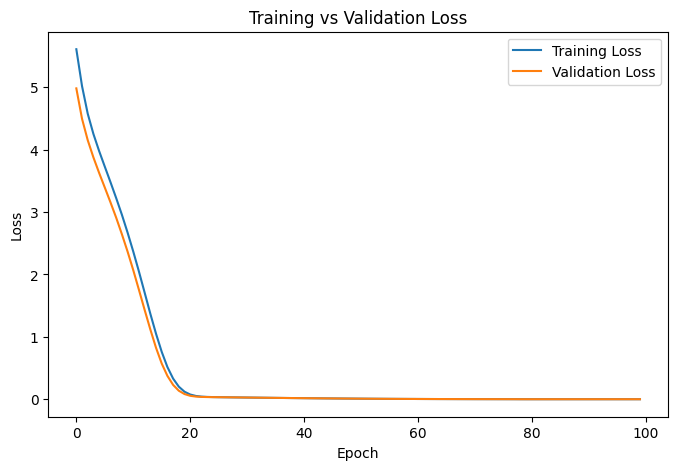

In [13]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history['loss'],

    label='Training Loss'

)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss'

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


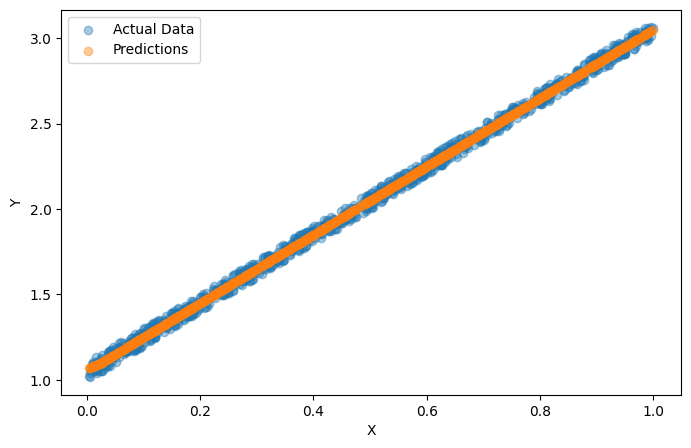

In [ ]:
predictions = model.predict(X)

plt.figure(figsize=(8,5))

plt.scatter(

    X,
    y,

    alpha=0.4,

    label="Actual Data"

)

plt.scatter(

    X,
    predictions,

    alpha=0.4,

    label="Predictions"

)

plt.xlabel("X")

plt.ylabel("Y")

plt.legend()

plt.show()predictions = model.predict(X)

plt.figure(figsize=(8,5))

plt.scatter(

    X,
    y,

    alpha=0.4,

    label="Actual Data"

)

plt.scatter(

    X,
    predictions,

    alpha=0.4,

    label="Predictions"

)

plt.xlabel("X")

plt.ylabel("Y")

plt.legend()

plt.show()predictions = model.predict(X)

plt.figure(figsize=(8,5))

plt.scatter(

    X,
    y,

    alpha=0.4,

    label="Actual Data"

)

plt.scatter(

    X,
    predictions,

    alpha=0.4,

    label="Predictions"

)

plt.xlabel("X")

plt.ylabel("Y")
predictions = model.predict(X)

plt.figure(figsize=(8,5))

plt.scatter(

    X,
    y,

    alpha=0.4,

    label="Actual Data"

)

plt.scatter(

    X,
    predictions,

    alpha=0.4,

    label="Predictions"

)

plt.xlabel("X")

plt.ylabel("Y")

plt.legend()

plt.show()predictions = model.predict(X)

plt.figure(figsize=(8,5))

plt.scatter(

    X,
    y,

    alpha=0.4,

    label="Actual Data"

)

plt.scatter(

    X,
    predictions,

    alpha=0.4,

    label="Predictions"

)

plt.xlabel("X")

plt.ylabel("Y")

plt.legend()

plt.show()
plt.legend()

plt.show()

In [15]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split

# =====================================
# DATA
# =====================================

X = np.array([

    [1],
    [2],
    [3],
    [4],
    [5],
    [6]

])

y = np.array([

    [0],
    [0],
    [0],
    [1],
    [1],
    [1]

])

# =====================================
# SPLIT DATA
# =====================================

X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.33,

    random_state=42

)

print("Training Data:")
print(X_train)

print("\nValidation Data:")
print(X_val)

# =====================================
# MODEL
# =====================================

model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        4,
        activation='relu',
        input_shape=(1,)
    ),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )

])

# =====================================
# COMPILE
# =====================================

model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

# =====================================
# TRAIN
# =====================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=100,

    verbose=1

)

# =====================================
# EVALUATE
# =====================================

loss, accuracy = model.evaluate(

    X_val,
    y_val,

    verbose=0

)

print("\nValidation Accuracy:", accuracy)

Training Data:
[[6]
 [3]
 [5]
 [4]]

Validation Data:
[[1]
 [2]]
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.4617 - val_accuracy: 0.0000e+00 - val_loss: 0.9959
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7500 - loss: 0.4615 - val_accuracy: 0.0000e+00 - val_loss: 0.9929
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7500 - loss: 0.4613 - val_accuracy: 0.0000e+00 - val_loss: 0.9899
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7500 - loss: 0.4611 - val_accuracy: 0.0000e+00 - val_loss: 0.9871
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7500 - loss: 0.4610 - val_accuracy: 0.0000e+00 - val_loss: 0.9846
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7500 - loss: 0.4609 - val_accuracy: 0.0000e+00 - val_loss: 0.9823
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7500 - loss: 0.4607 - val_accuracy: 0.0000e+00 - val_loss: 0.9805
Epoch 8/100
1/1 ━━━━━━━━━━